<a href="https://colab.research.google.com/github/kravtsova2/Trajectories-in-physical-and-shape-spaces/blob/main/Physical_and_shape_trajectories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from scipy import stats
from scipy.spatial import distance_matrix
!pip install pot
import ot

In [3]:
data_dir = Path("../compute_ot_dataset")

distances_path = data_dir / "ot_distances.npy"
times_path = data_dir / "times.npy"
centroids_path = data_dir / "centroids.npy"

In [4]:
shape_distances = np.load(distances_path, allow_pickle=True)
T = np.load(times_path, allow_pickle=True)
C = np.load(centroids_path, allow_pickle=True)

shape_distances = list(shape_distances)
T = list(T)
C = list(C)

In [5]:
ind_straight = np.array([
    0, 1, 2, 4, 5, 6, 7, 11, 12, 15, 41, 50, 65, 77, 78, 80, 85, 86
])

ind_nonstraight = np.array([
    20, 21, 28, 44, 49, 63, 87, 91, 100, 101, 102, 103,
    105, 106, 107, 110, 111, 113
])

In [6]:
def angle_between_vectors(v1, v2):
    dot_product = np.dot(v1, v2)

    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    if norm_v1 == 0 or norm_v2 == 0:
        return np.nan

    cosine_angle = np.clip(
        dot_product / (norm_v1 * norm_v2),
        -1.0,
        1.0
    )

    return np.arccos(cosine_angle)

In [7]:
phys_turn = []
phys_dist = []
shape_change = []
rphys = []

for i in range(len(C)):
    centroids = np.asarray(C[i])
    times = np.asarray(T[i])
    shape_steps = np.asarray(shape_distances[i])

    if len(centroids) < 2:
        phys_turn.append(np.nan)
        phys_dist.append(np.nan)
        shape_change.append(np.nan)
        rphys.append(np.nan)
        continue

    total_time = times[-1] - times[0]

    if total_time <= 0:
        phys_turn.append(np.nan)
        phys_dist.append(np.nan)
        shape_change.append(np.nan)
        rphys.append(np.nan)
        continue

    velocity_vectors = np.diff(centroids, axis=0)

    angles = []

    for j in range(len(velocity_vectors) - 1):
        angle_rad = angle_between_vectors(
            velocity_vectors[j],
            velocity_vectors[j + 1]
        )
        angles.append(np.degrees(angle_rad))

    physical_steps = np.linalg.norm(
        np.diff(centroids, axis=0),
        axis=1
    )

    physical_path_length = np.nansum(physical_steps)

    physical_displacement = np.linalg.norm(
        centroids[-1] - centroids[0]
    )

    shape_path_length = np.nansum(shape_steps)

    phys_turn.append(np.nansum(angles) / total_time)
    phys_dist.append(physical_path_length / total_time)
    shape_change.append(shape_path_length / total_time)

    rphys.append(
        physical_displacement / physical_path_length
        if physical_path_length > 0 else np.nan
    )


phys_turn = np.array(phys_turn)
vbarphys = np.array(phys_dist)
vbarshape = np.array(shape_change)
rphys = np.array(rphys)

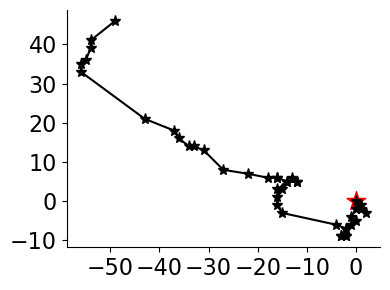

In [8]:
i = 0

cell_idx = ind_straight[i]
sorted_Centroid = np.asarray(C[cell_idx])

traj = sorted_Centroid - sorted_Centroid[0]

plt.figure(figsize=(4, 3))

plt.plot(
    traj[:, 0],
    traj[:, 1],
    "-*",
    c="black",
    markersize=8
)

plt.scatter(
    traj[0, 0],
    traj[0, 1],
    color="red",
    marker="*",
    s=200
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig("trajectory_straight.svg", format="svg", bbox_inches="tight")
plt.show()

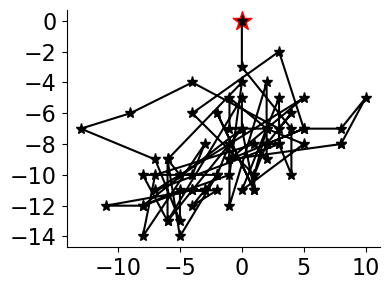

In [9]:
i = 12

cell_idx = ind_nonstraight[i]
sorted_Centroid = np.asarray(C[cell_idx])

traj = sorted_Centroid - sorted_Centroid[0]

plt.figure(figsize=(4, 3))

plt.plot(
    traj[:, 0],
    traj[:, 1],
    "-*",
    c="black",
    markersize=8
)

plt.scatter(
    traj[0, 0],
    traj[0, 1],
    color="red",
    marker="*",
    s=200
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig("trajectory_nonstraight.svg", format="svg", bbox_inches="tight")
plt.show()

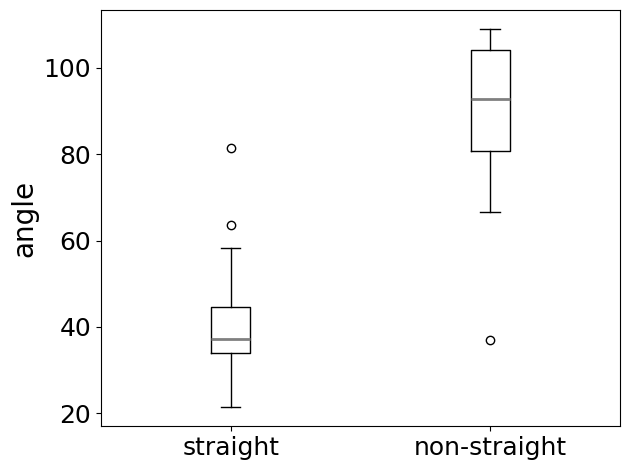

p_value 6.853075316024524e-10


In [10]:
pstraight = [
    phys_turn[i]
    for i in ind_straight
    if i < len(phys_turn) and np.isfinite(phys_turn[i])
]

pchaotic = [
    phys_turn[i]
    for i in ind_nonstraight
    if i < len(phys_turn) and np.isfinite(phys_turn[i])
]

d_plot = [pstraight, pchaotic]

fig, ax = plt.subplots()

ax.boxplot(
    d_plot,
    medianprops=dict(color="gray", linewidth=2),
    labels=["straight", "non-straight"]
)

ax.tick_params(axis="both", labelsize=18)
ax.set_ylabel("angle", fontsize=20)
ax.set_xlabel("")

plt.tight_layout()
plt.savefig("fig3_boxplot.svg")
plt.show()

t_statistic, p_value = stats.ttest_ind(
    np.array(pstraight),
    np.array(pchaotic),
    nan_policy="omit"
)

print("p_value",p_value)

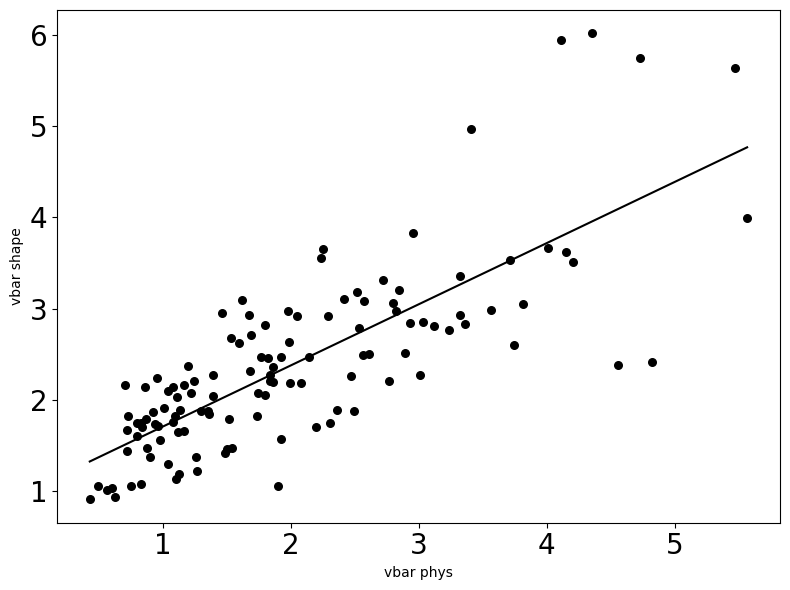

regression results for vbar
Slope: 0.6701156729117212
Intercept: 1.037347611111677
R-squared: 0.6064967476551617
P-value: 7.39548234858914e-26
Standard error: 0.04948074384304122


In [11]:
x = np.array(vbarphys)
y = np.array(vbarshape)

mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_pred = slope * x_line + intercept

plt.figure(figsize=(8, 6))

plt.scatter(x, y, color="black", s=30)
plt.plot(x_line, y_pred, color="black")

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel("vbar phys")
plt.ylabel("vbar shape")

plt.tight_layout()
plt.savefig("fig4a.svg")
plt.show()

print("regression results for vbar")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value ** 2}")
print(f"P-value: {p_value}")
print(f"Standard error: {std_err}")

In [12]:
shape_displacement = np.load(
    data_dir / "first_last_shape_distances.npy",
    allow_pickle=True
)

shape_displacement = np.asarray(shape_displacement, dtype=float)

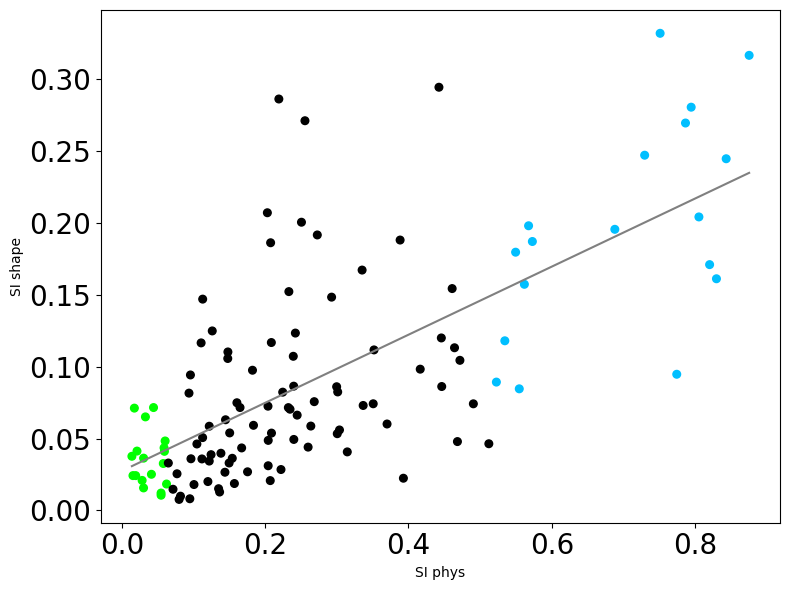

colored SI regression
R-squared: 0.4760127351645446
P-value: 2.090075775427674e-18


In [13]:
rshape = []

for i in range(len(shape_distances)):
    shape_steps = np.asarray(shape_distances[i], dtype=float)
    shape_path_length = np.nansum(shape_steps)

    if shape_path_length > 0 and np.isfinite(shape_displacement[i]):
        rshape.append(shape_displacement[i] / shape_path_length)
    else:
        rshape.append(np.nan)

rshape = np.array(rshape)

group = np.zeros(len(rphys), dtype=int)

for i in ind_straight:
    if i < len(group):
        group[i] = 1

for i in ind_nonstraight:
    if i < len(group):
        group[i] = 2

x = np.array(rphys)
y = np.array(rshape)

mask = np.isfinite(x) & np.isfinite(y)

df_si = pd.DataFrame({
    "x": x[mask],
    "y": y[mask],
    "group": group[mask]
})

colors = []

for g in df_si["group"]:
    if g == 1:
        colors.append("deepskyblue")
    elif g == 2:
        colors.append("lime")
    else:
        colors.append("black")

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_si["x"],
    df_si["y"]
)

x_line = np.linspace(df_si["x"].min(), df_si["x"].max(), 100)
y_pred = slope * x_line + intercept

plt.figure(figsize=(8, 6))

plt.scatter(df_si["x"], df_si["y"], c=colors, s=30)
plt.plot(x_line, y_pred, color="gray")

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel("SI phys")
plt.ylabel("SI shape")

plt.tight_layout()
plt.savefig("fig4b_SI_colored.svg")
plt.show()

print("colored SI regression")
print(f"R-squared: {r_value ** 2}")
print(f"P-value: {p_value}")